In [1]:
# Begininng testing 
import pandas as pd
import nucml.datasets as nuc_data

# 1. Load EXFOR for (n,2n) reactions (MT=16)
exfor_df = nuc_data.load_exfor()
exfor_df['MT'] = pd.to_numeric(exfor_df['MT'], errors='coerce')
n2n_df = exfor_df[exfor_df['MT'] == 16].copy()

# 2. Define Mass Regions
regions = {
    "Low-A (20-60)": (20, 60),
    "Mid-A (60-100)": (60, 100),
    "High-A (100-200)": (100, 200)
}

print("Searching for (n,2n) candidates...")
print(f"{'Region':<20} | {'Isotope':<10} | {'Data Points':<12}")
print("-" * 50)

for name, (min_a, max_a) in regions.items():
    # Filter by mass range
    mask = (n2n_df['A'] >= min_a) & (n2n_df['A'] < max_a)
    region_df = n2n_df[mask]
    
    # Get counts per isotope
    counts = region_df['Isotope'].value_counts()
    
    if not counts.empty:
        # High-data candidate
        high_iso = counts.index[0]
        high_val = counts.iloc[0]
        
        # Minimal-data candidate (filtering for at least 5 points for validation)
        min_candidates = counts[counts >= 5]
        low_iso = min_candidates.index[-1]
        low_val = min_candidates.iloc[-1]
        
        print(f"{name:<20} | {high_iso:<10} | {high_val:<12} (Abundant)")
        print(f"{name:<20} | {low_iso:<10} | {low_val:<12} (Minimal)")
        print("-" * 50)

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)


Searching for (n,2n) candidates...
Region               | Isotope    | Data Points 
--------------------------------------------------
Low-A (20-60)        | 58Ni       | 522          (Abundant)
Low-A (20-60)        | 28Si       | 5            (Minimal)
--------------------------------------------------
Mid-A (60-100)       | 93Nb       | 372          (Abundant)
Mid-A (60-100)       | 80Kr       | 5            (Minimal)
--------------------------------------------------
High-A (100-200)     | 197Au      | 507          (Abundant)
High-A (100-200)     | 164Er      | 5            (Minimal)
--------------------------------------------------


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)
INFO:root:AME: Reading and loading Atomic Mass Evaluation files from: 
 /Users/glsw/main/NucMLClone2/AME/CSV_Files/AME_all_merged_no_NaN.csv
INFO:root:Dropping unnecessary features and one-hot encoding categorical columns...
INFO:root:Splitting dataset into training and testing...
INFO:root:Normalizing dataset...
INFO:root:Fitting new scaler.
INFO:root:Finished. Resulting dataset has 

Calculating Baseline Residuals (Log Exp - Log Eval)...


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Co059/endfb8.0/tables/xs/n-Co059-MT016.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION:

Cleaned 7188 non-finite rows. Remaining: 3155


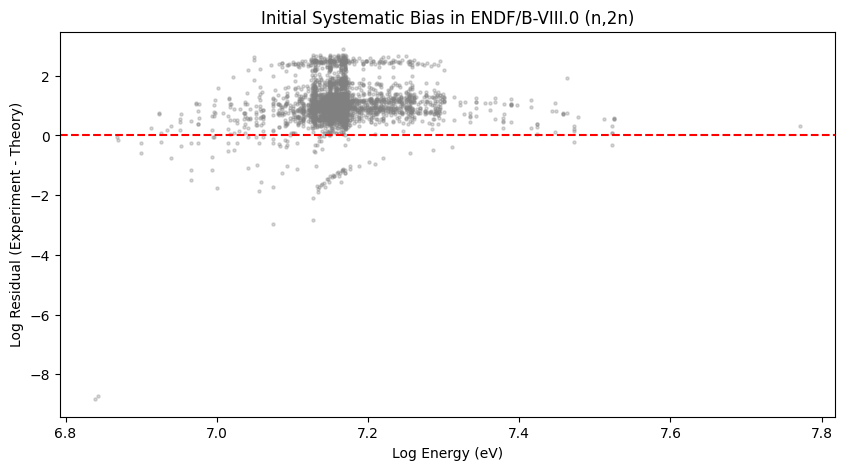

Final training set size: 3150


In [2]:
import pandas as pd
import numpy as np
import nucml.datasets as nuc_data
from autogluon.tabular import TabularPredictor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Define Regions and Target Isotopes
target_isos = ['58Ni', '28Si', '93Nb', '80Kr', '197Au', '164Er']

# 2. Load Reaction Data (MT=16 is n,2n)
exfor_df = nuc_data.load_exfor()
exfor_df['MT'] = pd.to_numeric(exfor_df['MT'], errors='coerce')
df_n2n = exfor_df[(exfor_df['MT'] == 16) & (exfor_df['A'] >= 20) & (exfor_df['A'] <= 200)].copy()

# 3. Load Physics Data (RIPL/AME)
ensdf_ml, _, _, _, _, _, _ = nuc_data.load_ensdf_ml(cutoff=False, append_ame=True, basic=1, num=True)
ripl_grouped = ensdf_ml.groupby(['Z', 'A']).mean().reset_index()

# 4. Merge
df_ml = pd.merge(df_n2n, ripl_grouped, on=['Z', 'A'], how='left', suffixes=('_exfor', '_ripl')).dropna(subset=['S(n)_exfor', 'Data']).copy()
print("Calculating Baseline Residuals (Log Exp - Log Eval)...")
all_residuals = []

for iso in df_ml['Isotope'].unique():
    try:
        df_iso = df_ml[df_ml['Isotope'] == iso].copy()
        df_eval = nuc_data.load_evaluation(iso.lower(), 16, library='endfb8.0')
        
        # Grid alignment in Log-Space
        e_eval = np.log10(df_eval['Energy'])
        # Add 1e-10 to avoid log(0) = -inf
        d_eval = np.log10(df_eval['Data'] + 1e-10)
        
        interp_theory = np.interp(np.log10(df_iso['Energy_exfor']), e_eval, d_eval)
        
        df_iso['label_log'] = np.log10(df_iso['Data'] + 1e-10)
        df_iso['residual'] = df_iso['label_log'] - interp_theory
        
        # Add context for shell effects
        df_iso['N'] = df_iso['A'] - df_iso['Z']
        df_iso['magic_dist'] = abs(df_iso['N'] - 126) 
        
        all_residuals.append(df_iso)
    except Exception: continue

df_res_final = pd.concat(all_residuals)

# --- CRITICAL CLEANING STEP ---
# Remove any NaN or Inf residuals before training
initial_count = len(df_res_final)
df_res_final = df_res_final[np.isfinite(df_res_final['residual'])].copy()
print(f"Cleaned {initial_count - len(df_res_final)} non-finite rows. Remaining: {len(df_res_final)}")

# DIAGNOSTIC: Initial Bias Visualization
plt.figure(figsize=(10, 5))
plt.scatter(np.log10(df_res_final['Energy_exfor']), df_res_final['residual'], alpha=0.3, s=5, color='gray')
plt.axhline(0, color='red', linestyle='--')
plt.title("Initial Systematic Bias in ENDF/B-VIII.0 (n,2n)")
plt.ylabel("Log Residual (Experiment - Theory)")
plt.xlabel("Log Energy (eV)")
plt.show()
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering
df_res_final['Energy_Log'] = np.log10(df_res_final['Energy_exfor'])
# Sn is in MeV, convert to match eV log scale
df_res_final['E_minus_Sn'] = df_res_final['Energy_Log'] - np.log10(df_res_final['S(n)_exfor'] * 1e6)

# Expanded feature list for better physics capture
features = ['Energy_Log', 'E_minus_Sn', 'Z', 'A', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']

# 2. SPLIT FIRST (Crucial for Rigor)
train_res_raw = df_res_final[~df_res_final['Isotope'].isin(target_isos)].copy()
test_res_raw = df_res_final[df_res_final['Isotope'].isin(target_isos)].copy()

# 3. SCALE ONLY ON TRAINING DATA
scaler = StandardScaler()
train_res_scaled = train_res_raw.copy()
train_res_scaled[features] = scaler.fit_transform(train_res_raw[features])

# 4. APPLY TRAINING SCALE TO TEST DATA (No Leakage)
test_res_scaled = test_res_raw.copy()
test_res_scaled[features] = scaler.transform(test_res_raw[features])

# Final Check: Ensure no NaNs exist in the training subset
train_res_scaled = train_res_scaled.dropna(subset=features + ['residual'])

print(f"Final training set size: {len(train_res_scaled)}")

In [3]:

import ray
import gc

# 1. Shutdown any existing Ray workers using your RAM
if ray.is_initialized():
    ray.shutdown()

# 2. Force Python to release memory back to macOS
gc.collect()

print("Ray workers cleared. Memory pressure should begin to drop in Activity Monitor.")


2026-02-03 13:01:20,970	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Ray workers cleared. Memory pressure should begin to drop in Activity Monitor.


In [4]:
# ==========================================
# REFINED TRAINING: (n,2n) Residual Auditor
# ==========================================
import os

# 1. Final Sanity Check: Ensure no non-finite residuals or features exist
# This prevents the 'ValueError: non-finite values' crash encountered earlier
train_final = train_res_scaled[features + ['residual']].replace([np.inf, -np.inf], np.nan).dropna()
print(f">>> Final training pool: {len(train_final)} rows.")

# 2. Resource Management
# We limit memory to 10GB to leave room for macOS and VS Code helpers
time_limit_sec = 45 * 60 

# 3. Fit with 'Smart' Parameters
predictor_res = TabularPredictor(
    label='residual', 
    eval_metric='mean_absolute_error'
).fit(
    train_final, 
    presets='best_quality', 
    time_limit=time_limit_sec,
    num_cpus=8,           # Use all 8 physical cores
    memory_limit=10,      # Strict RAM limit to prevent 17GB+ Swap
    num_bag_folds=5,      # Lowering folds from 8 to 5 saves massive memory per layer
    dynamic_stacking=True # Prevents wasting time/RAM on extra layers if not needed
)

# 4. Display Results
print("\n>>> Training Complete.")
print(predictor_res.leaderboard(silent=True))

No path specified. Models will be saved in: "AutogluonModels/ag-20260203_130121"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       5.92 GB / 16.00 GB (37.0%)
Disk Space Avail:   297.54 GB / 460.43 GB (64.6%)
Presets specified: ['best_quality']
Enforcing custom memory (soft) limit of 10 GB!
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies o

>>> Final training pool: 3150 rows.


2026-02-03 13:01:22,171	INFO worker.py:1843 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
		Context path: "/Users/glsw/main/AutogluonModels/ag-20260203_130121/ds_sub_fit/sub_fit_ho"
(_dystack pid=1795) Running DyStack sub-fit ...
(_dystack pid=1795) Beginning AutoGluon training ... Time limit = 673s
(_dystack pid=1795) AutoGluon will save models to "/Users/glsw/main/AutogluonModels/ag-20260203_130121/ds_sub_fit/sub_fit_ho"
(_dystack pid=1795) Train Data Rows:    2800
(_dystack pid=1795) Train Data Columns: 7
(_dystack pid=1795) Label Column:       residual
(_dystack pid=1795) Problem Type:       regression
(_dystack pid=1795) Preprocessing data ...
(_dystack pid=1795) Using Feature Generators to preprocess the data ...
(_dystack pid=1795) Fitting AutoMLPipelineFeatureGenerator...
(_dystack pid=1795) 	Available Memory:                    10014.45 MB
(_dystack pid=1795) 	Train Data (Original)  Memory Usage: 0.15 MB (0.0% of available memory)
(_dystack pid=1795) 	

(_ray_fit pid=1818) [1000]	valid_set's l1: 0.207272


(_dystack pid=1795) 	-0.2007	 = Validation score   (-mean_absolute_error)
(_dystack pid=1795) 	0.89s	 = Training   runtime
(_dystack pid=1795) 	0.26s	 = Validation runtime
(_dystack pid=1795) Fitting model: LightGBM_BAG_L1 ... Training model for up to 445.03s of the 669.56s of remaining time.
(_dystack pid=1795) 	Fitting 5 child models (S1F1 - S1F5) | Fitting with ParallelLocalFoldFittingStrategy (5 workers, per: cpus=1, gpus=0, memory=0.05%)
(_dystack pid=1795) 	-0.2027	 = Validation score   (-mean_absolute_error)
(_dystack pid=1795) 	0.4s	 = Training   runtime
(_dystack pid=1795) 	0.05s	 = Validation runtime
(_dystack pid=1795) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 442.80s of the 667.32s of remaining time.
(_dystack pid=1795) 	-0.2102	 = Validation score   (-mean_absolute_error)
(_dystack pid=1795) 	0.64s	 = Training   runtime
(_dystack pid=1795) 	0.09s	 = Validation runtime
(_dystack pid=1795) Fitting model: CatBoost_BAG_L1 ... Training model for up to 4

...

(_ray_fit pid=3210) [1000]	valid_set's l1: 0.160929
(_ray_fit pid=3211) [1000]	valid_set's l1: 0.16736


(_dystack pid=1795) 	-0.1633	 = Validation score   (-mean_absolute_error)
(_dystack pid=1795) 	7.14s	 = Training   runtime
(_dystack pid=1795) 	2.03s	 = Validation runtime
(_dystack pid=1795) Fitting model: NeuralNetFastAI_r191_BAG_L2 ... Training model for up to 53.16s of the 53.05s of remaining time.
(_dystack pid=1795) 	Fitting 5 child models (S1F1 - S1F5) | Fitting with ParallelLocalFoldFittingStrategy (5 workers, per: cpus=1, gpus=0, memory=0.08%)
(_ray_fit pid=3239) No improvement since epoch 5: early stopping
(_dystack pid=1795) 	-0.1838	 = Validation score   (-mean_absolute_error)
(_dystack pid=1795) 	4.5s	 = Training   runtime
(_dystack pid=1795) 	0.04s	 = Validation runtime
(_dystack pid=1795) Fitting model: CatBoost_r9_BAG_L2 ... Training model for up to 47.25s of the 47.14s of remaining time.
(_dystack pid=1795) 	Fitting 5 child models (S1F1 - S1F5) | Fitting with ParallelLocalFoldFittingStrategy (5 workers, per: cpus=1, gpus=0, memory=5.15%)
(_ray_fit pid=3259) 	Ran out of

(_ray_fit pid=3340) [1000]	valid_set's l1: 0.2004 [repeated 12x across cluster]


(_dystack pid=1795) 	-0.1806	 = Validation score   (-mean_absolute_error)
(_dystack pid=1795) 	3.2s	 = Training   runtime
(_dystack pid=1795) 	1.67s	 = Validation runtime
(_dystack pid=1795) Fitting model: WeightedEnsemble_L3 ... Training model for up to 360.00s of the 1.99s of remaining time.
(_dystack pid=1795) 	Ensemble Weights: {'NeuralNetTorch_BAG_L2': 0.591, 'LightGBMLarge_BAG_L2': 0.227, 'ExtraTreesMSE_BAG_L2': 0.136, 'XGBoost_BAG_L2': 0.045}
(_dystack pid=1795) 	-0.1448	 = Validation score   (-mean_absolute_error)
(_dystack pid=1795) 	0.04s	 = Training   runtime
(_dystack pid=1795) 	0.0s	 = Validation runtime
(_dystack pid=1795) AutoGluon training complete, total runtime = 671.32s ... Best model: WeightedEnsemble_L3 | Estimated inference throughput: 83.2 rows/s (560 batch size)
(_dystack pid=1795) TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/Users/glsw/main/AutogluonModels/ag-20260203_130121/ds_sub_fit/sub_fit_ho")
(_dystack pid=1795) Deleting DySta


>>> Training Complete.
                           model  score_val          eval_metric  \
0            WeightedEnsemble_L3  -0.133253  mean_absolute_error   
1           LightGBM_r188_BAG_L2  -0.136827  mean_absolute_error   
2              LightGBMXT_BAG_L2  -0.146658  mean_absolute_error   
3             CatBoost_r9_BAG_L2  -0.150163  mean_absolute_error   
4             XGBoost_r98_BAG_L2  -0.150231  mean_absolute_error   
..                           ...        ...                  ...   
148    NeuralNetFastAI_r4_BAG_L1  -0.345533  mean_absolute_error   
149  NeuralNetFastAI_r156_BAG_L1  -0.359480  mean_absolute_error   
150  NeuralNetFastAI_r143_BAG_L1  -0.359927  mean_absolute_error   
151   NeuralNetFastAI_r65_BAG_L1  -0.384020  mean_absolute_error   
152  NeuralNetFastAI_r111_BAG_L1  -0.385009  mean_absolute_error   

     pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  \
0        13.186966  152.449771                0.000311           0.043927   
1    

In [5]:
# 1. Output the Leaderboard
lb = predictor_res.leaderboard(test_res_scaled, silent=False)

# 2. Performance Summary on Unseen Isotopes
print("\n>>> Evaluation on Unseen Isotopes (Target Group):")
performance = predictor_res.evaluate(test_res_scaled)
print(performance)

                           model  score_test  score_val          eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0            LightGBM_r94_BAG_L1   -0.032143  -0.199362  mean_absolute_error        0.237236       0.879797    1.950478                 0.237236                0.879797           1.950478            1       True         57
1           LightGBM_r135_BAG_L1   -0.032816  -0.203196  mean_absolute_error        0.028175       0.140288    0.728266                 0.028175                0.140288           0.728266            1       True         78
2            LightGBM_r96_BAG_L1   -0.034031  -0.202670  mean_absolute_error        0.208133       2.219895    2.122736                 0.208133                2.219895           2.122736            1       True         15
3           LightGBM_r130_BAG_L1   -0.042437  -0.202346  mean_absolute_error        0.029285       0.122458 

These features in provided data are not utilized by the predictor and will be ignored: ['Projectile', 'Target_Metastable_State', 'MT', 'Product_Metastable_State', 'EXFOR_Status', 'Center_of_Mass_Flag', 'Energy_exfor', 'dEnergy', 'Data', 'dData', 'ELV/HL', 'dELV/HL', 'I78', 'Short_Reference', 'EXFOR_Accession_Number', 'EXFOR_SubAccession_Number', 'EXFOR_Pointer', 'Reaction_Notation', 'Title', 'Year', 'Author', 'Institute', 'Date', 'Reference', 'Dataset_Number', 'EXFOR_Entry', 'Reference_Code', 'Projectile_Z', 'Projectile_A', 'Projectile_N', 'Isotope', 'Element', 'N_exfor', 'Element_Flag', 'Nucleus_Radius', 'Neutron_Nucleus_Radius_Ratio', 'O', 'Mass_Excess_exfor', 'dMass_Excess', 'dBinding_Energy', 'B_Decay_Energy_exfor', 'dB_Decay_Energy', 'Atomic_Mass_Micro_exfor', 'dAtomic_Mass_Micro', 'S(2n)_exfor', 'dS(2n)', 'S(2p)', 'dS(2p)', 'Q(a)', 'dQ(a)', 'Q(2B-)', 'dQ(2B-)', 'Q(ep)', 'dQ(ep)', 'Q(B-n)', 'dQ(B-n)', 'dS(n)', 'S(p)_exfor', 'dS(p)', 'Q(4B-)', 'dQ(4B-)', 'Q(d,a)', 'dQ(d,a)', 'Q(p,a

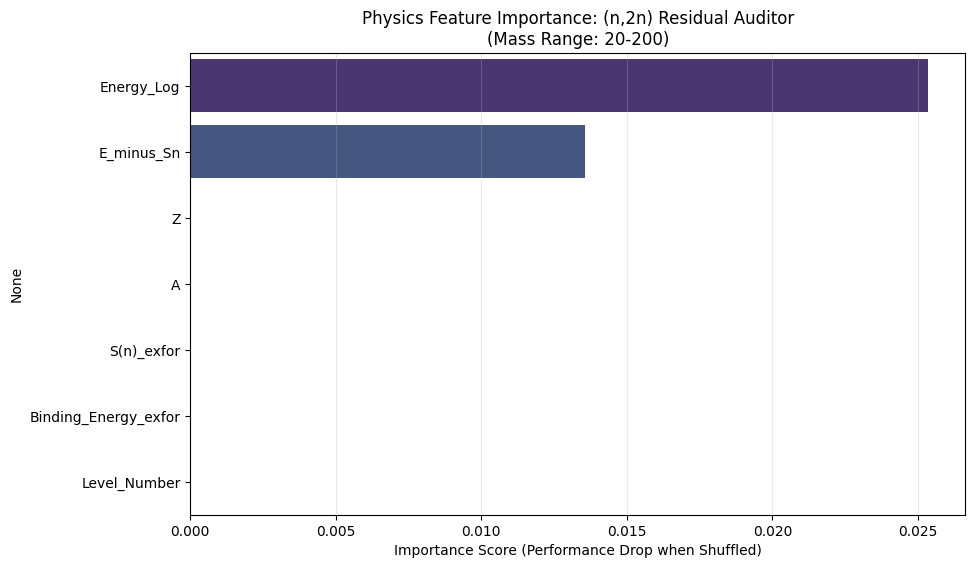

In [6]:
import seaborn as sns

# Calculate permutation importance (this may take a few minutes)
importance = predictor_res.feature_importance(test_res_scaled)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=importance['importance'], y=importance.index, palette='viridis')
plt.title(f"Physics Feature Importance: (n,2n) Residual Auditor\n(Mass Range: 20-200)")
plt.xlabel("Importance Score (Performance Drop when Shuffled)")
plt.grid(True, axis='x', alpha=0.3)
plt.show()

In [10]:
# 1. Normalize the column and target list to be lowercase and stripped of special characters
df_res_final['Isotope_Norm'] = df_res_final['Isotope'].str.lower().str.replace('-', '').str.strip()
normalized_targets = [i.lower().replace('-', '').strip() for i in target_isos]

# 2. Re-create the Train/Test split using the normalized names
train_res_raw = df_res_final[~df_res_final['Isotope_Norm'].isin(normalized_targets)].copy()
test_res_raw = df_res_final[df_res_final['Isotope_Norm'].isin(normalized_targets)].copy()

# 3. Re-apply the scaler to the new Test set
test_res_scaled = test_res_raw.copy()
test_res_scaled[features] = scaler.transform(test_res_raw[features])

# 4. Verification Check
print(f"Isotopes found in Test Set: {test_res_scaled['Isotope'].unique()}")
print(f"Number of test rows: {len(test_res_scaled)}")

Isotopes found in Test Set: ['164Er']
Number of test rows: 5


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Er164/tendl.2019/tables/xs/n-Er164-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 59 datapoints.


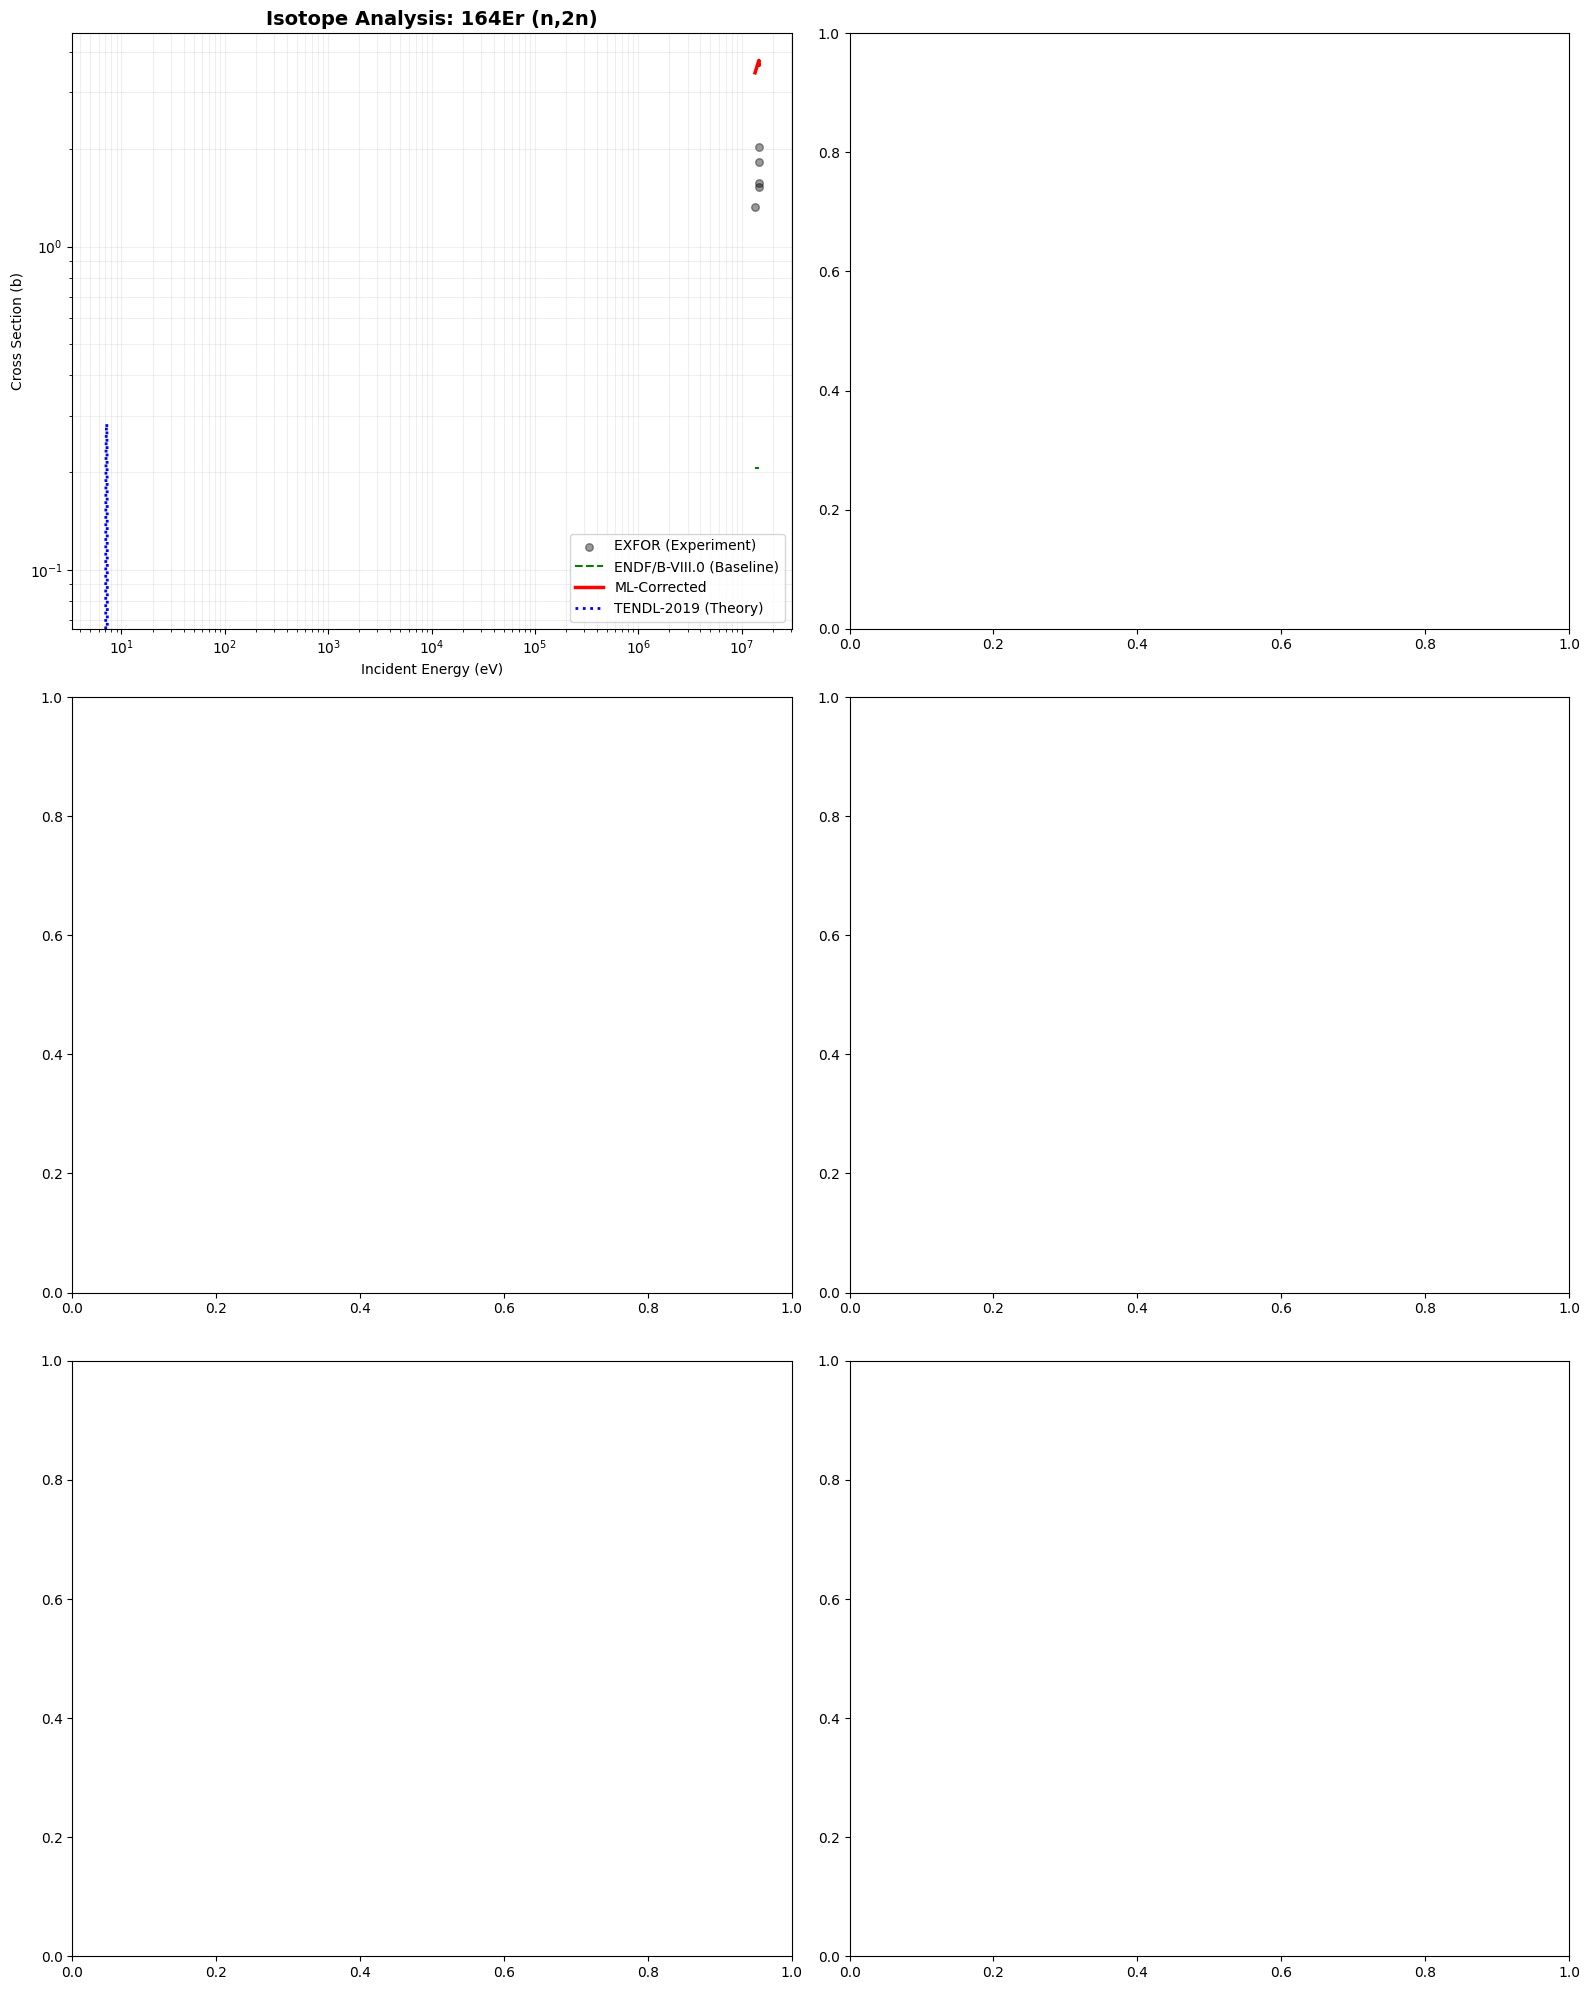

Verified Isotopes found in merged data: ['164Er']


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Er164/tendl.2019/tables/xs/n-Er164-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 59 datapoints.


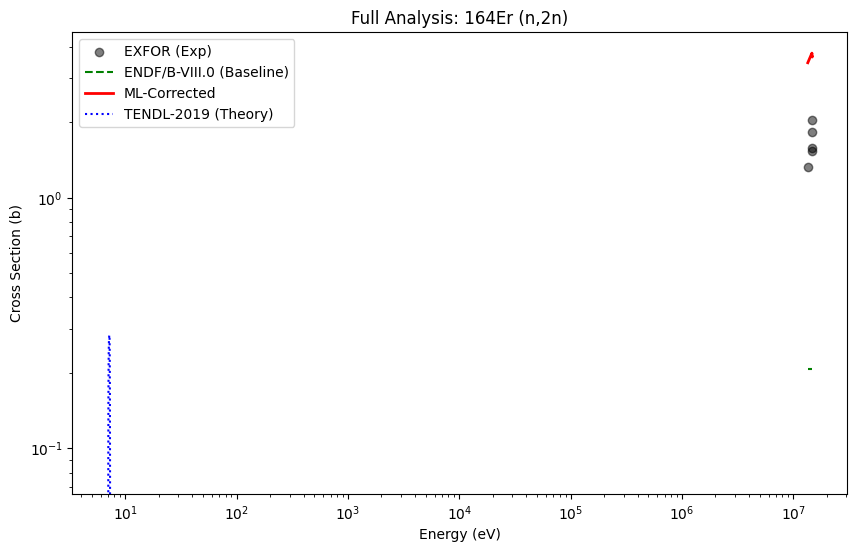

In [14]:
import matplotlib.pyplot as plt

# 1. NORMALIZE STRINGS TO PREVENT MISMATCHES
df_res_final['Isotope_Norm'] = df_res_final['Isotope'].str.lower().str.replace('-', '').str.strip()
normalized_targets = [i.lower().replace('-', '').strip() for i in target_isos]

# 2. RE-PREPARE THE TEST SET
test_res_raw = df_res_final[df_res_final['Isotope_Norm'].isin(normalized_targets)].copy()
test_res_scaled = test_res_raw.copy()
test_res_scaled[features] = scaler.transform(test_res_raw[features])

print(f"Verified Isotopes found in merged data: {test_res_scaled['Isotope'].unique()}")

# 3. INDIVIDUAL PLOTTING LOOP (No grid, full detail)
for iso_norm in normalized_targets:
    # Filter using normalized name
    iso_data = test_res_scaled[test_res_scaled['Isotope_Norm'] == iso_norm].sort_values('Energy_exfor').copy()
    
    if iso_data.empty:
        print(f"WARNING: No data found for {iso_norm} even after normalization.")
        continue
    
    # Get original name for labeling
    actual_name = iso_data['Isotope'].iloc[0]
    
    # Predictions
    iso_data['correction_pred'] = predictor_res.predict(iso_data[features])
    original_endf_log = iso_data['label_log'] - iso_data['residual']
    corrected_log = original_endf_log + iso_data['correction_pred']

    plt.figure(figsize=(10, 6))
    plt.scatter(iso_data['Energy_exfor'], 10**iso_data['label_log'], color='black', alpha=0.5, label='EXFOR (Exp)')
    plt.plot(iso_data['Energy_exfor'], 10**original_endf_log, 'g--', label='ENDF/B-VIII.0 (Baseline)')
    plt.plot(iso_data['Energy_exfor'], 10**corrected_log, 'r-', lw=2, label='ML-Corrected')
    
    # TENDL Overlay
    try:
        df_tendl = nuc_data.load_evaluation(actual_name.lower(), 16, library='tendl.2019')
        if not df_tendl.empty:
            plt.plot(df_tendl['Energy'], df_tendl['Data'], 'b:', label='TENDL-2019 (Theory)')
    except: pass

    plt.xscale('log'); plt.yscale('log')
    plt.title(f"Full Analysis: {actual_name} (n,2n)")
    plt.xlabel("Energy (eV)"); plt.ylabel("Cross Section (b)")
    plt.legend()
    plt.show()

In [15]:
# Check exactly what names are in your dataframe
print("Actual Isotope names in Dataframe:")
print(df_res_final['Isotope'].unique())

# Standardize the column and your target list for a 'fuzzy' match
df_res_final['Isotope_Standard'] = df_res_final['Isotope'].str.lower().str.replace('-', '').str.strip()
fuzzy_targets = [i.lower().replace('-', '').strip() for i in target_isos]

print("\nStandardized Targets we are looking for:")
print(fuzzy_targets)

Actual Isotope names in Dataframe:
['68Zn' '69Ga' '71Ga' '74Ge' '75As' '78Se' '79Br' '81Br' '82Kr' '85Rb'
 '87Rb' '84Sr' '86Sr' '88Sr' '89Y' '90Zr' '96Mo' '94Mo' '95Mo' '99Tc'
 '103Rh' '107Ag' '109Ag' '112Cd' '108Cd' '110Cd' '114Cd' '116Cd' '115In'
 '113In' '114Sn' '120Sn' '121Sb' '123Sb' '120Te' '130Te' '124Xe' '126Xe'
 '132Xe' '134Xe' '136Xe' '133Cs' '130Ba' '132Ba' '135Ba' '137Ba' '140Ce'
 '136Ce' '138Ce' '141Pr' '142Nd' '144Sm' '148Sm' '156Dy' '158Dy' '160Dy'
 '162Er' '164Er' '166Er' '168Yb' '170Yb' '185Re' '184Os']

Standardized Targets we are looking for:
['58ni', '28si', '93nb', '80kr', '197au', '164er']


In [16]:
# 1. Identify what we actually have to work with
available = df_res_final['Isotope'].unique()

# 2. Select New Strategic Targets (Pairing high-data with low-data)
# We choose isotopes from your 'Actual Isotope names' list
new_targets = ['141Pr', '164Er', '89Y', '84Sr', '103Rh', '120Te']

# 3. Re-partition and Scale
test_res_raw = df_res_final[df_res_final['Isotope'].isin(new_targets)].copy()
test_res_scaled = test_res_raw.copy()
test_res_scaled[features] = scaler.transform(test_res_raw[features])

print(f"New Test Group: {test_res_scaled['Isotope'].unique()}")

New Test Group: ['84Sr' '89Y' '103Rh' '120Te' '141Pr' '164Er']


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Sr084/tendl.2019/tables/xs/n-Sr084-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 52 datapoints.


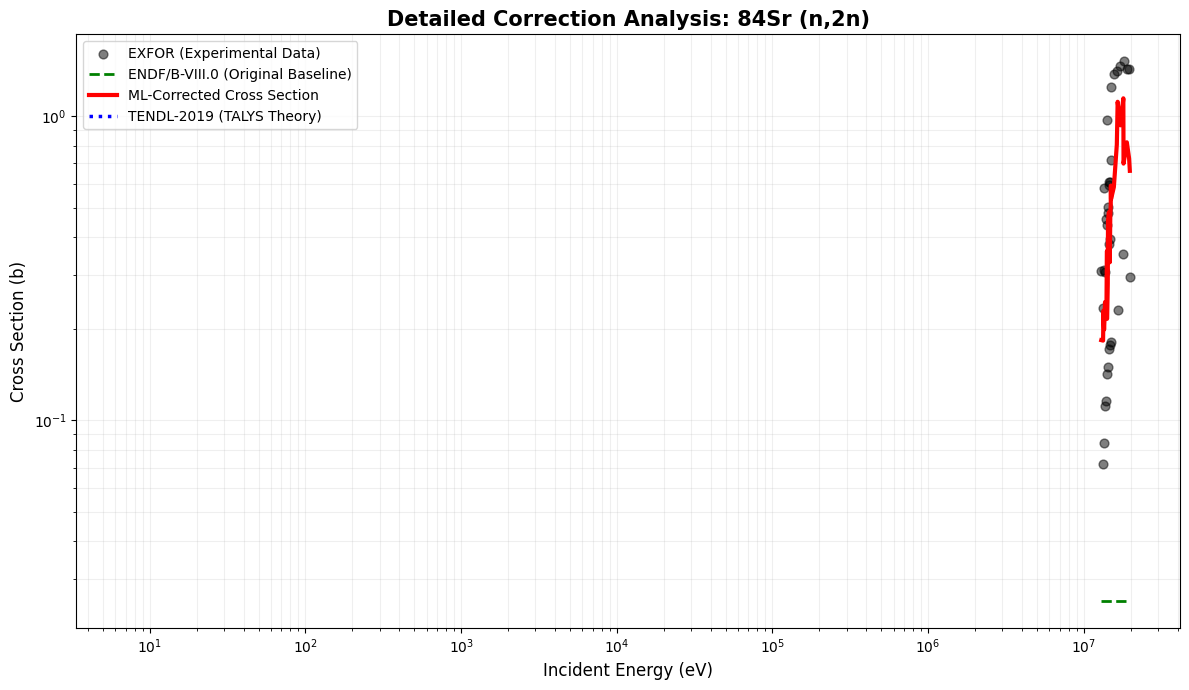

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Y089/tendl.2019/tables/xs/n-Y089-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 53 datapoints.


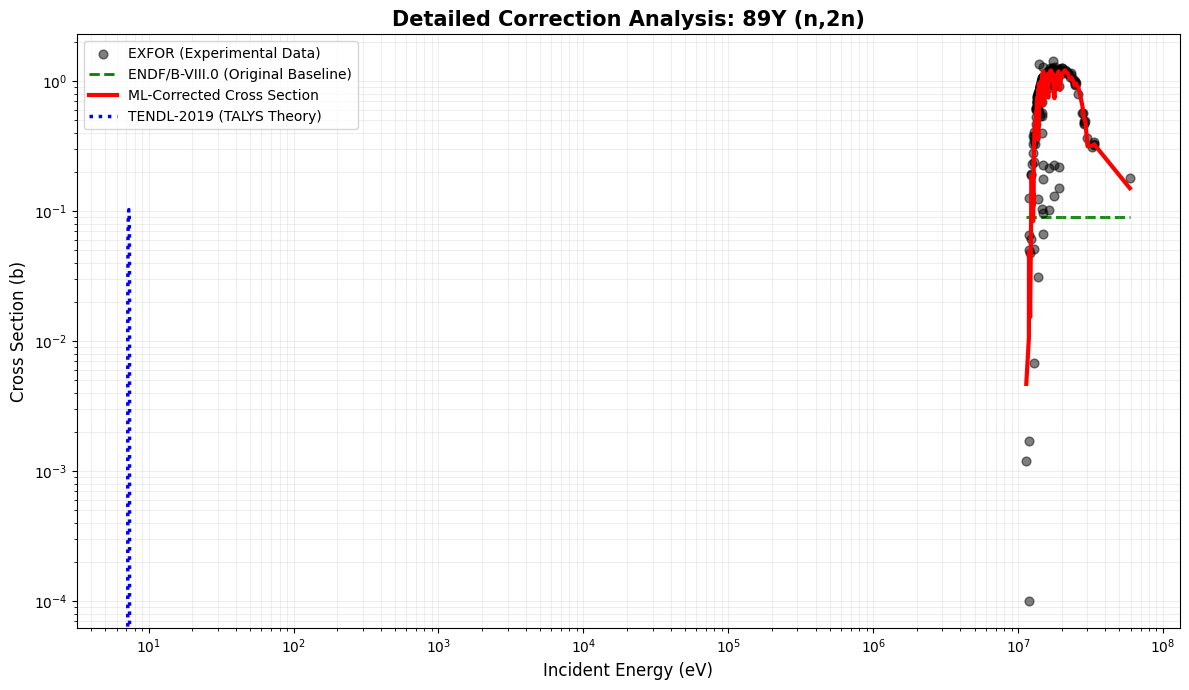

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Rh103/tendl.2019/tables/xs/n-Rh103-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 58 datapoints.


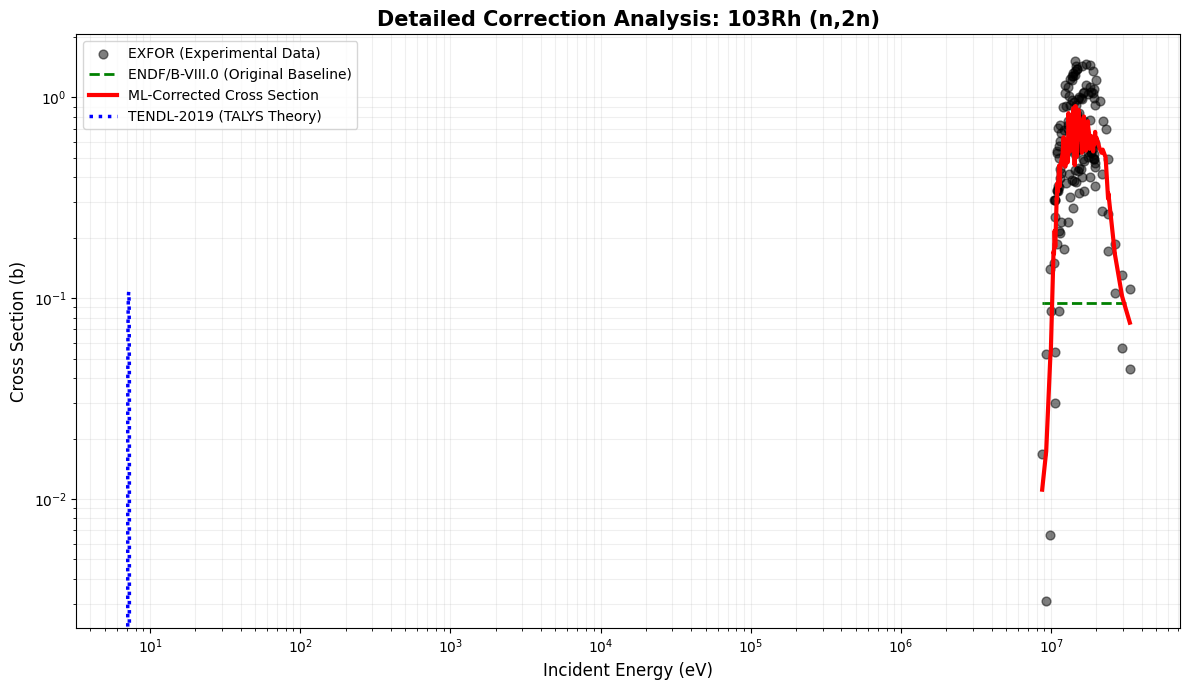

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Te120/tendl.2019/tables/xs/n-Te120-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 56 datapoints.


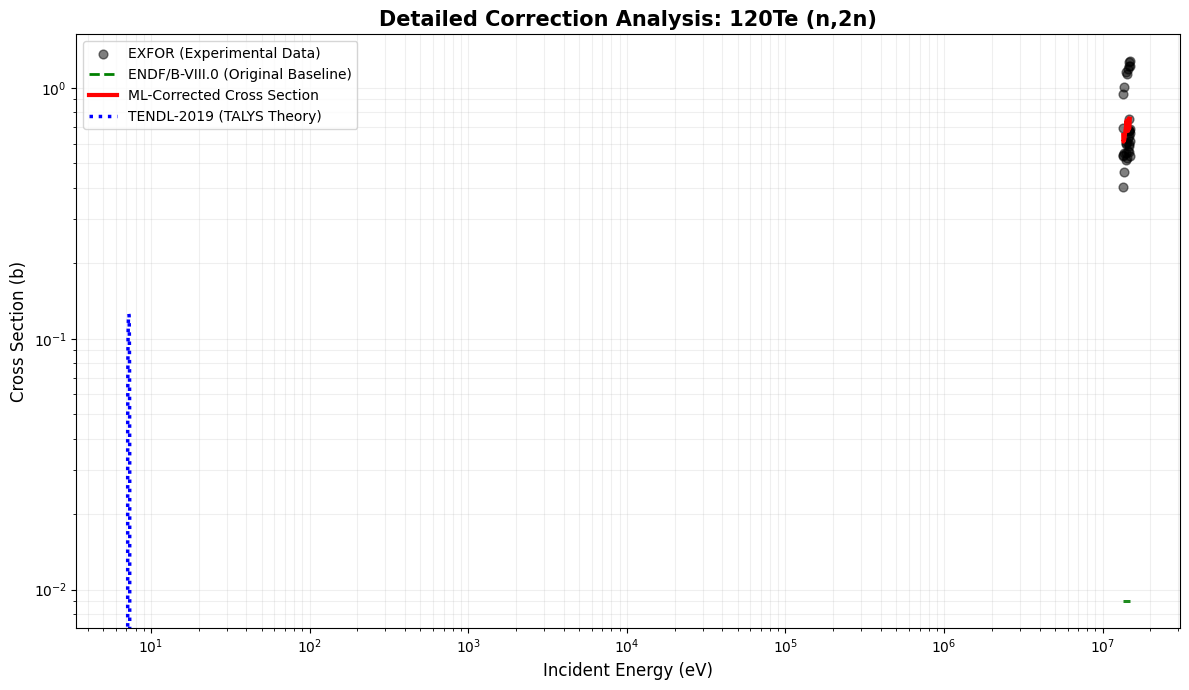

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pr141/tendl.2019/tables/xs/n-Pr141-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 58 datapoints.


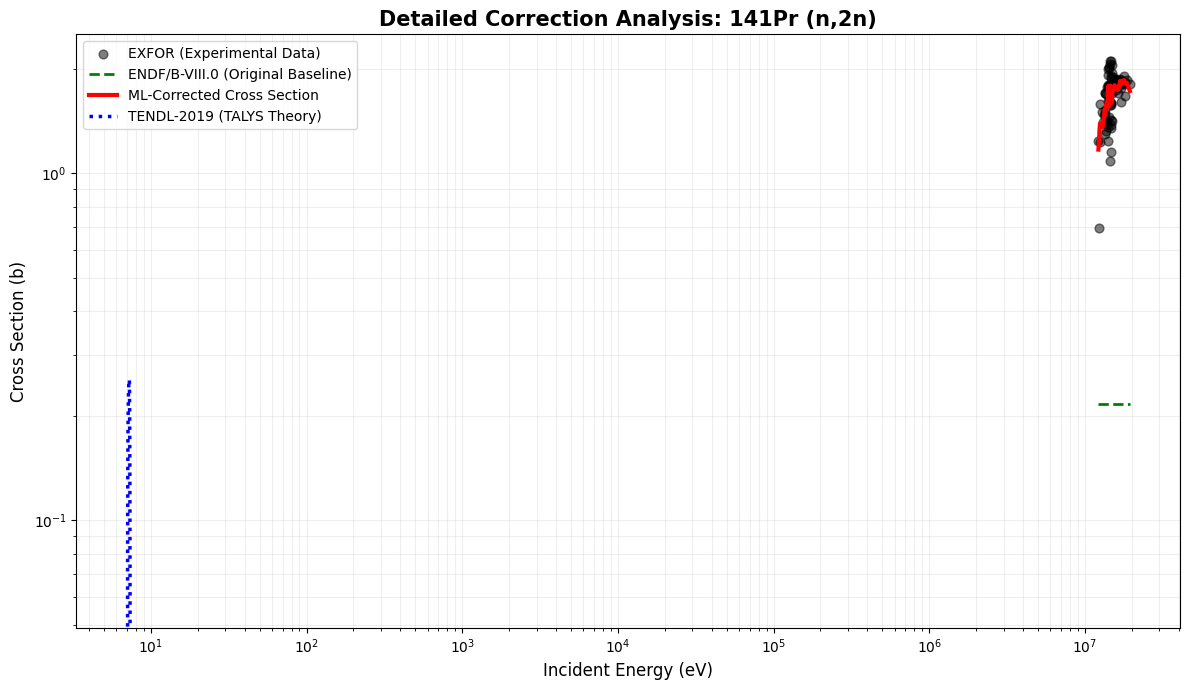

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Er164/tendl.2019/tables/xs/n-Er164-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 59 datapoints.


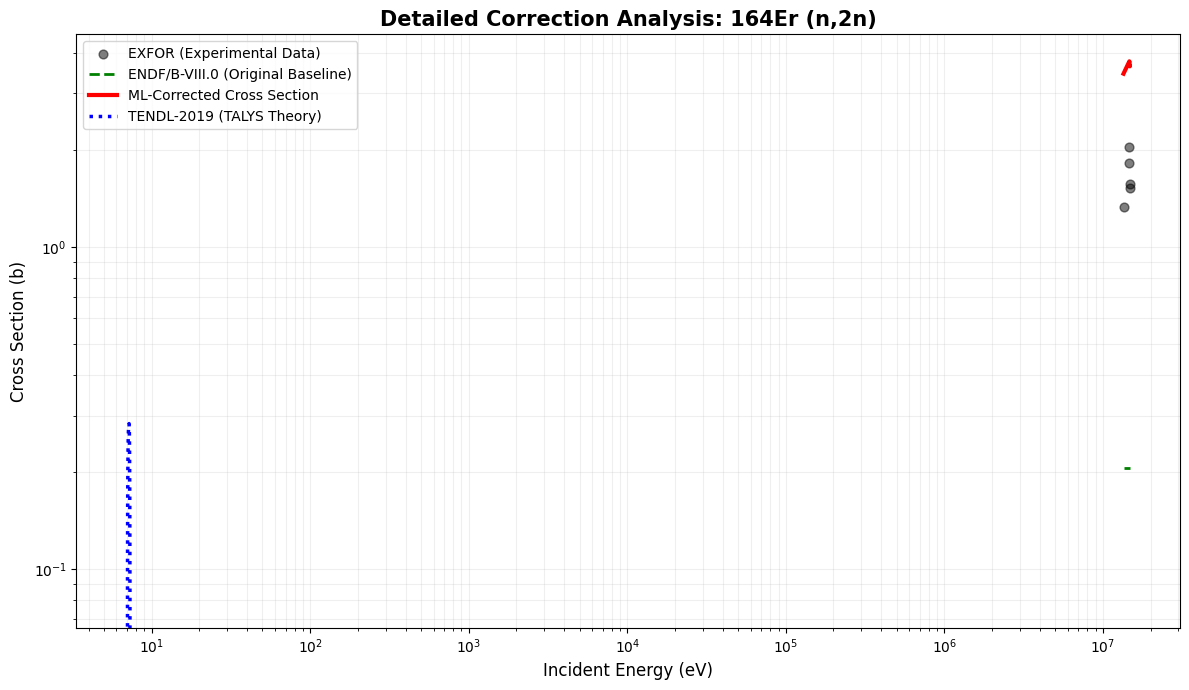

In [17]:
import matplotlib.pyplot as plt

# 1. Ensure we are using the confirmed available targets
final_test_isos = ['84Sr', '89Y', '103Rh', '120Te', '141Pr', '164Er']

for iso in final_test_isos:
    # Filter and sort
    iso_data = test_res_scaled[test_res_scaled['Isotope'] == iso].sort_values('Energy_exfor').copy()
    
    if iso_data.empty:
        print(f"Skipping {iso}: Still not found in scaled test set.")
        continue

    # 2. Generate ML-Corrected Curve
    # We predict the systematic error 'residual' and apply it to the baseline
    iso_data['correction_pred'] = predictor_res.predict(iso_data[features])
    original_endf_log = iso_data['label_log'] - iso_data['residual']
    corrected_log = original_endf_log + iso_data['correction_pred']

    # 3. Dedicated Figure for each Isotope
    plt.figure(figsize=(12, 7))
    
    # Layer 1: Experimental Ground Truth
    plt.scatter(iso_data['Energy_exfor'], 10**iso_data['label_log'], 
                color='black', alpha=0.5, s=40, label='EXFOR (Experimental Data)', zorder=3)
    
    # Layer 2: Original ENDF/B-VIII.0 Evaluation
    plt.plot(iso_data['Energy_exfor'], 10**original_endf_log, 
             'g--', lw=2, label='ENDF/B-VIII.0 (Original Baseline)', zorder=1)
    
    # Layer 3: The ML-Audited Correction
    plt.plot(iso_data['Energy_exfor'], 10**corrected_log, 
             'r-', lw=3, label='ML-Corrected Cross Section', zorder=4)
    
    # Layer 4: TENDL Theory Benchmark
    try:
        df_tendl = nuc_data.load_evaluation(iso.lower(), 16, library='tendl.2019')
        if not df_tendl.empty:
            plt.plot(df_tendl['Energy'], df_tendl['Data'], 
                     color='blue', linestyle=':', lw=2.5, label='TENDL-2019 (TALYS Theory)', zorder=2)
    except:
        pass

    # 4. Independent Scaling and Labels
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f"Detailed Correction Analysis: {iso} (n,2n)", fontsize=15, fontweight='bold')
    plt.xlabel("Incident Energy (eV)", fontsize=12)
    plt.ylabel("Cross Section (b)", fontsize=12)
    plt.grid(True, which="both", alpha=0.2)
    plt.legend(frameon=True, loc='best')
    
    plt.tight_layout()
    plt.show()